In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score


In [27]:
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.check_multicollinearity import check_multicollinearity 
from utils.calculate_regression_metrics import calculate_regression_metrics

In [28]:
MACRO_COLS = ['CPI_Change', 'Rate_Change', 'GDP_Growth', 'Unemp_Change', 'USD_Change', 'VIX_Change', 'Credit_Spread']
LAGGED_COLS =[
    'CPI_Change_lag1',
    'GDP_Growth_lag2',
    'Unemp_Change_lag1',
    'Credit_Spread_lag2'
    ]

In [29]:
df = pd.read_csv('../data/processed/processed_data.csv',parse_dates=['Date'])

# df.info()

# Prepare Data without Lags
splits_data = data_split(df,MACRO_COLS)

X_train = splits_data['X_train']
y_train = splits_data['y_train']

X_test  = splits_data['X_test']
y_test  = splits_data['y_test']



  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (7): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread


In [30]:

# MODEL 1: Linear Regression (7 variables, NO lags)

print("\n" + "="*50)
print("MODEL 1: Linear Regression (7 Variables - Baseline)")
print("="*50)


scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test)


# Train model
model_1 = LinearRegression()
model_1.fit(X_train_scaled, y_train)

# Predict
y_train_pred_1 = model_1.predict(X_train_scaled)
y_test_pred_1 = model_1.predict(X_test_scaled)



# Evaluate
# print("\nTRAINING SET:")
metrics_train_1 = calculate_regression_metrics(y_train, y_train_pred_1, "Model 1 - Train")

# print("\nTEST SET:")
metrics_test_1 = calculate_regression_metrics(y_test, y_test_pred_1, "Model 1 - Test")

# Print coefficients
coef_df_1 = pd.DataFrame({
    'Feature': MACRO_COLS,
    'Coefficient': model_1.coef_,
    'Abs_Coef': np.abs(model_1.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")
print(coef_df_1.to_string(index=False))


MODEL 1: Linear Regression (7 Variables - Baseline)

Model 1 - Train Performance:
  R²:                  0.3766
  RMSE:                3.222%
  MAE:                 2.434%
  Directional Accuracy: 75.43%

Model 1 - Test Performance:
  R²:                  0.0751
  RMSE:                4.826%
  MAE:                 3.545%
  Directional Accuracy: 73.91%

COEFFICIENTS:
      Feature  Coefficient  Abs_Coef
   VIX_Change    -2.381333  2.381333
Credit_Spread    -0.792480  0.792480
   USD_Change    -0.545496  0.545496
 Unemp_Change    -0.291311  0.291311
   CPI_Change    -0.225185  0.225185
  Rate_Change    -0.206304  0.206304
   GDP_Growth    -0.079954  0.079954


In [31]:
splits_data = data_split(df,MACRO_COLS + LAGGED_COLS)

X_train_lagged = splits_data['X_train']
y_train_lagged = splits_data['y_train']

X_test_lagged  = splits_data['X_test']
y_test_lagged  = splits_data['y_test']


  Train       n= 346  1991-03-01 to 2019-12-01  μ=0.63%  σ=4.08%

  Test        n=  69  2020-01-01 to 2025-09-01  μ=1.05%  σ=5.02%

  Features (11): CPI_Change, Rate_Change, GDP_Growth, Unemp_Change, USD_Change, VIX_Change, Credit_Spread, CPI_Change_lag1, GDP_Growth_lag2, Unemp_Change_lag1, Credit_Spread_lag2


In [32]:

# MODEL 2: Linear Regression With lags


print("\n" + "="*50)
print("MODEL 2: Linear Regression with lags")
print("="*50)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lagged)   # fit + transform on TRAIN only
X_test_scaled  = scaler.transform(X_test_lagged)

# Train model
model_2 = LinearRegression()
model_2.fit(X_train_lagged, y_train_lagged)

# Predict
y_train_pred_2 = model_2.predict(X_train_lagged)
y_test_pred_2 = model_2.predict(X_test_lagged)

# Evaluate
print("\nTRAINING SET:")
metrics_train_2 = calculate_regression_metrics(y_train_lagged, y_train_pred_2, "Model 2 - Train")

print("\nTEST SET:")
metrics_test_2 = calculate_regression_metrics(y_test_lagged, y_test_pred_2, "Model 2 - Test")

# Print coefficients
coef_df_2 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_2.coef_,
    'Abs_Coef': np.abs(model_2.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS:")
print(coef_df_2.to_string(index=False))




MODEL 2: Linear Regression with lags

TRAINING SET:

Model 2 - Train Performance:
  R²:                  0.3901
  RMSE:                3.187%
  MAE:                 2.409%
  Directional Accuracy: 74.86%

TEST SET:

Model 2 - Test Performance:
  R²:                  -0.3961
  RMSE:                5.930%
  MAE:                 4.286%
  Directional Accuracy: 65.22%

COEFFICIENTS:
           Feature  Coefficient  Abs_Coef
 Unemp_Change_lag1    -2.080726  2.080726
      Unemp_Change    -1.902879  1.902879
       Rate_Change    -1.721895  1.721895
     Credit_Spread    -1.553388  1.553388
        VIX_Change    -0.671882  0.671882
   GDP_Growth_lag2    -0.588178  0.588178
        CPI_Change    -0.571586  0.571586
        GDP_Growth     0.548416  0.548416
   CPI_Change_lag1     0.470366  0.470366
        USD_Change    -0.307114  0.307114
Credit_Spread_lag2     0.118506  0.118506


In [33]:
# Check for multicollinearity

X_train_lagged_df = pd.DataFrame(X_train_lagged, columns=MACRO_COLS + LAGGED_COLS)
print("\nMULTICOLLINEARITY CHECK (VIF):")
vif_results = check_multicollinearity(X_train_lagged_df, threshold=5.0)


MULTICOLLINEARITY CHECK (VIF):

Variance Inflation Factor (VIF):
           Feature       VIF Concern
   GDP_Growth_lag2 89.635238    High
        GDP_Growth 89.230883    High
     Credit_Spread 52.412648    High
Credit_Spread_lag2 50.373382    High
        CPI_Change  2.232127      OK
   CPI_Change_lag1  1.977570      OK
 Unemp_Change_lag1  1.295880      OK
      Unemp_Change  1.261845      OK
       Rate_Change  1.242026      OK
        VIX_Change  1.106060      OK
        USD_Change  1.088589      OK

Note: VIF > 5.0 indicates multicollinearity concern


In [ ]:
# MODEL 3: Ridge Regression

print("\n" + "="*50)
print("MODEL 3: Ridge Regression")
print("="*50)


alphas = np.logspace(-3, 5, 100)

# Manually compute CV score for each alpha
cv_scores = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    scores = cross_val_score(
        ridge, 
        X_train_lagged, 
        y_train_lagged, 
        cv=5, 
        scoring='r2'
    )
    cv_scores.append(scores.mean())

cv_scores = np.array(cv_scores)

# Find best alpha manually
best_alpha = alphas[np.argmax(cv_scores)]
print(f"Best alpha: {best_alpha:.4f}")


MODEL 3: Ridge Regression
Best alpha: 178.8650


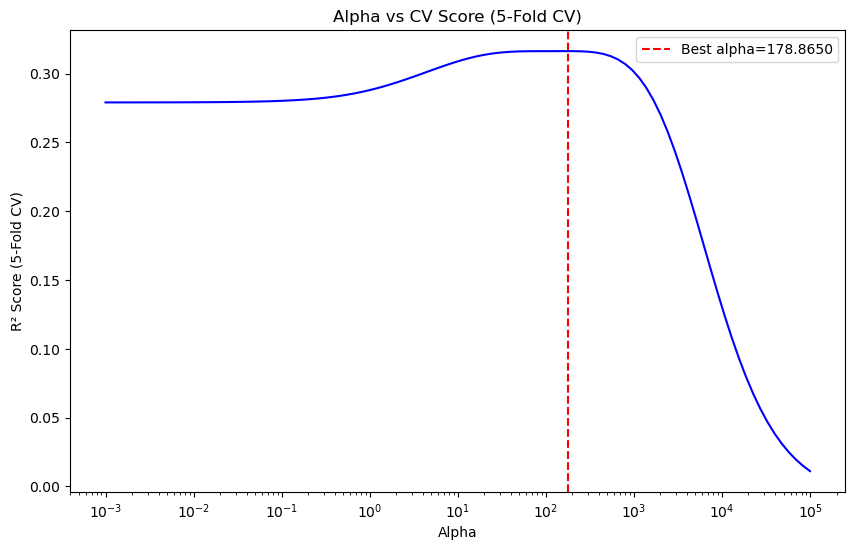

In [35]:
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, cv_scores, color='blue')
plt.axvline(best_alpha, color='red', linestyle='--',
            label=f'Best alpha={best_alpha:.4f}')
plt.xlabel('Alpha')
plt.ylabel('R² Score (5-Fold CV)')
plt.title('Alpha vs CV Score (5-Fold CV)')
plt.legend()
plt.show()

In [36]:

# Train final Ridge model with best alpha

model_3_ridge = Ridge(alpha=best_alpha)
model_3_ridge.fit(X_train_lagged, y_train_lagged)

# Predict
y_train_pred_3 = model_3_ridge.predict(X_train_lagged)
y_test_pred_3 = model_3_ridge.predict(X_test_lagged)

# Evaluate
print("\nTRAINING SET:")
metrics_train_3 = calculate_regression_metrics(y_train_lagged, y_train_pred_3, "Model 3 - Train")

print("\nTEST SET:")
metrics_test_3 = calculate_regression_metrics(y_test_lagged, y_test_pred_3, "Model 3 - Test")

# Print coefficients (on scaled features)
coef_df_3 = pd.DataFrame({
    'Feature': MACRO_COLS + LAGGED_COLS,
    'Coefficient': model_3_ridge.coef_,
    'Abs_Coef': np.abs(model_3_ridge.coef_)
}).sort_values('Abs_Coef', ascending=False)

print("\nCOEFFICIENTS (on standardized scale):")
print(coef_df_3.to_string(index=False))


TRAINING SET:

Model 3 - Train Performance:
  R²:                  0.3614
  RMSE:                3.262%
  MAE:                 2.463%
  Directional Accuracy: 73.70%

TEST SET:

Model 3 - Test Performance:
  R²:                  0.2996
  RMSE:                4.200%
  MAE:                 3.192%
  Directional Accuracy: 72.46%

COEFFICIENTS (on standardized scale):
           Feature  Coefficient  Abs_Coef
        VIX_Change    -0.625514  0.625514
        GDP_Growth     0.267520  0.267520
     Credit_Spread    -0.244340  0.244340
        USD_Change    -0.243865  0.243865
Credit_Spread_lag2    -0.187977  0.187977
   CPI_Change_lag1     0.152076  0.152076
   GDP_Growth_lag2    -0.112609  0.112609
      Unemp_Change    -0.087879  0.087879
 Unemp_Change_lag1    -0.086825  0.086825
        CPI_Change    -0.083056  0.083056
       Rate_Change    -0.041352  0.041352


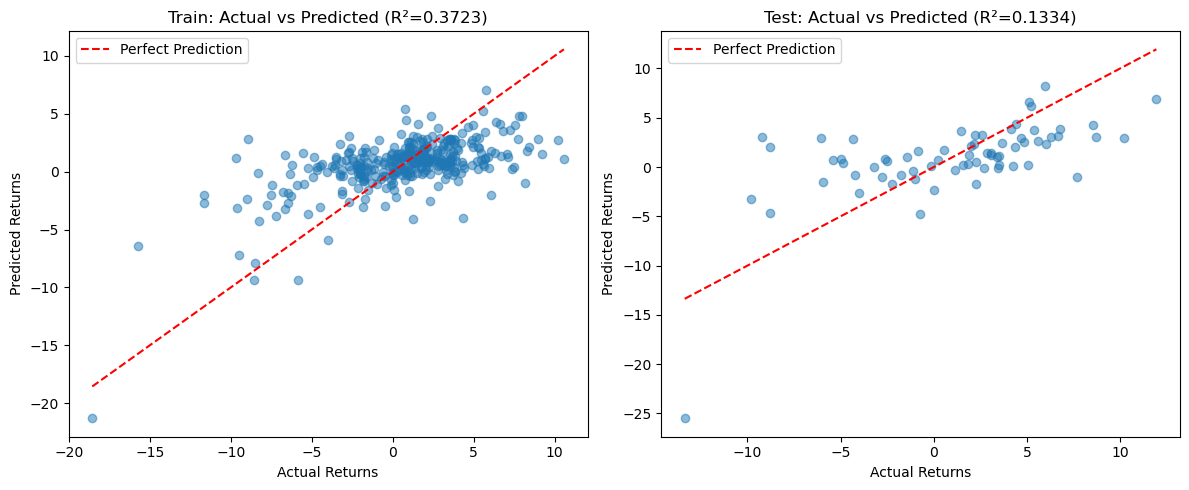

In [37]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1, 2, 1)
plt.scatter(y_train_lagged, y_train_pred_3, alpha=0.5)
plt.plot([y_train_lagged.min(), y_train_lagged.max()],
         [y_train_lagged.min(), y_train_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Train: Actual vs Predicted (R²=0.3723)')
plt.legend()

# Test
plt.subplot(1, 2, 2)
plt.scatter(y_test_lagged, y_test_pred_3, alpha=0.5)
plt.plot([y_test_lagged.min(), y_test_lagged.max()],
         [y_test_lagged.min(), y_test_lagged.max()], 
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.title(f'Test: Actual vs Predicted (R²=0.1334)')
plt.legend()

plt.tight_layout()
plt.show()

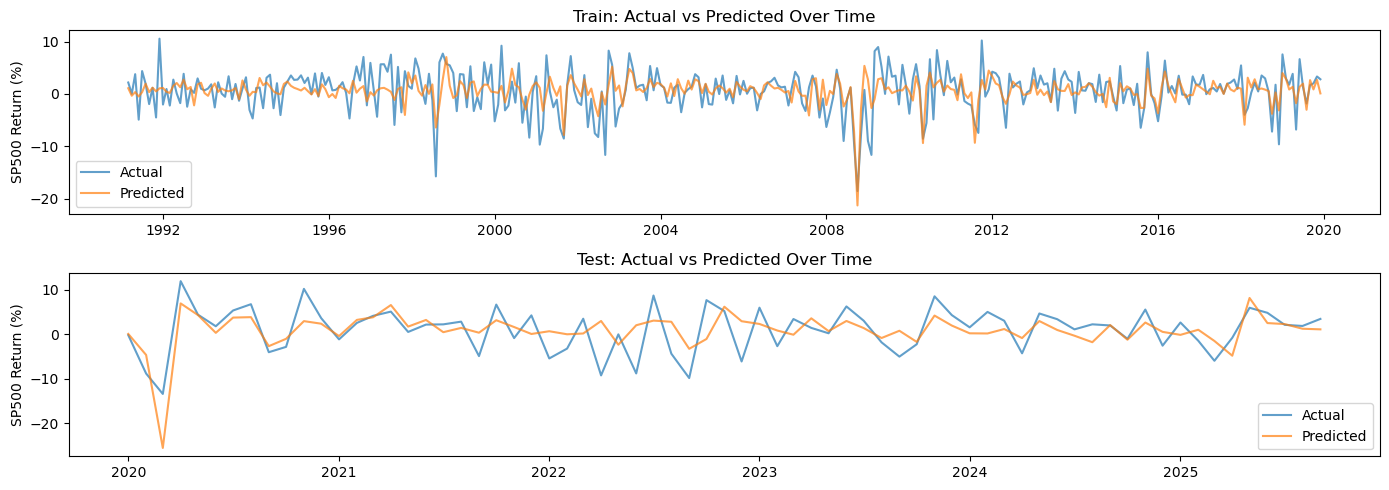

In [38]:
plt.figure(figsize=(14, 5))

dates_train,dates_test = splits_data['dates_train'], splits_data['dates_test']  
# Train
plt.subplot(2, 1, 1)
plt.plot(dates_train, y_train_lagged, label='Actual', alpha=0.7)
plt.plot(dates_train, y_train_pred_3,  label='Predicted', alpha=0.7)
plt.title('Train: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

# Test
plt.subplot(2, 1, 2)
plt.plot(dates_test, y_test_lagged, label='Actual', alpha=0.7)
plt.plot(dates_test, y_test_pred_3,  label='Predicted', alpha=0.7)
plt.title('Test: Actual vs Predicted Over Time')
plt.ylabel('SP500 Return (%)')
plt.legend()

plt.tight_layout()
plt.show()

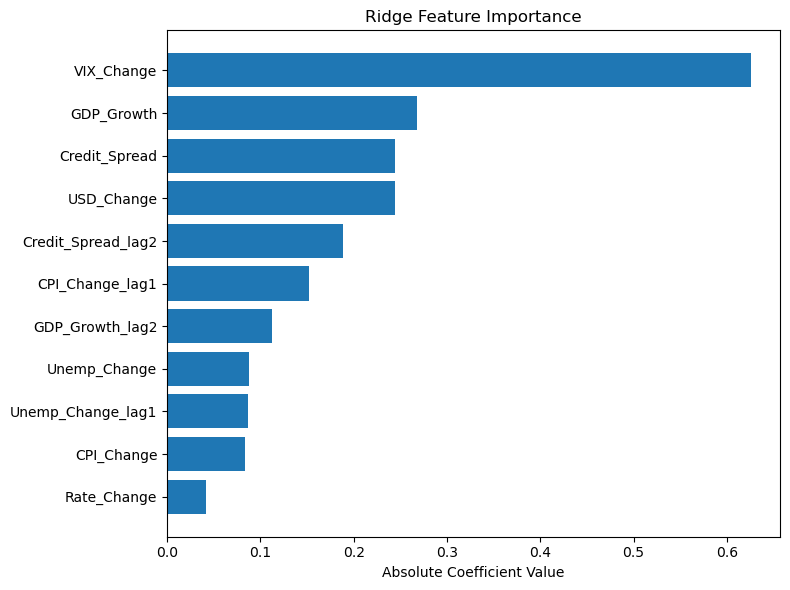

In [39]:
coef_df = pd.DataFrame({
    'Feature'    : MACRO_COLS + LAGGED_COLS,
    'Coefficient': np.abs(model_3_ridge.coef_)
}).sort_values('Coefficient', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Ridge Feature Importance')
plt.tight_layout()
plt.show()